In [7]:
import pandas as pd
df = pd.read_csv("SHOP_2015-05-21_2025-03-16.csv")
df.head()

,date,open,high,low,close,adj_close,volume
0,2015-05-21 00:00:00-04:00,2.800,2.874,2.411,2.568,2.568,123039000
1,2015-05-22 00:00:00-04:00,2.607,3.110,2.600,2.831,2.831,28412000
2,2015-05-26 00:00:00-04:00,2.980,3.034,2.908,2.965,2.965,8202000
3,2015-05-27 00:00:00-04:00,3.067,3.081,2.700,2.750,2.750,7976000
4,2015-05-28 00:00:00-04:00,2.755,2.774,2.648,2.745,2.745,4000000


In [31]:
df.columns

Index(['date', 'open', 'high', 'low', 'close', 'adj_close', 'volume'], dtype='object')

In [29]:
df['date'] = pd.to_datetime(df['date'], utc=True)  # Acepta timezone-aware
df['date'] = df['date'].dt.tz_localize(None)       # Elimina la zona horaria
df.info()


<class 'pandas.core.frame.DataFrame'>
RangeIndex: 2469 entries, 0 to 2468
Data columns (total 7 columns):
 #   Column     Non-Null Count  Dtype         
---  ------     --------------  -----         
 0   date       2469 non-null   datetime64[ns]
 1   open       2469 non-null   float64       
 2   high       2469 non-null   float64       
 3   low        2469 non-null   float64       
 4   close      2469 non-null   float64       
 5   adj_close  2469 non-null   float64       
 6   volume     2469 non-null   int64         
dtypes: datetime64[ns](1), float64(5), int64(1)
memory usage: 135.2 KB


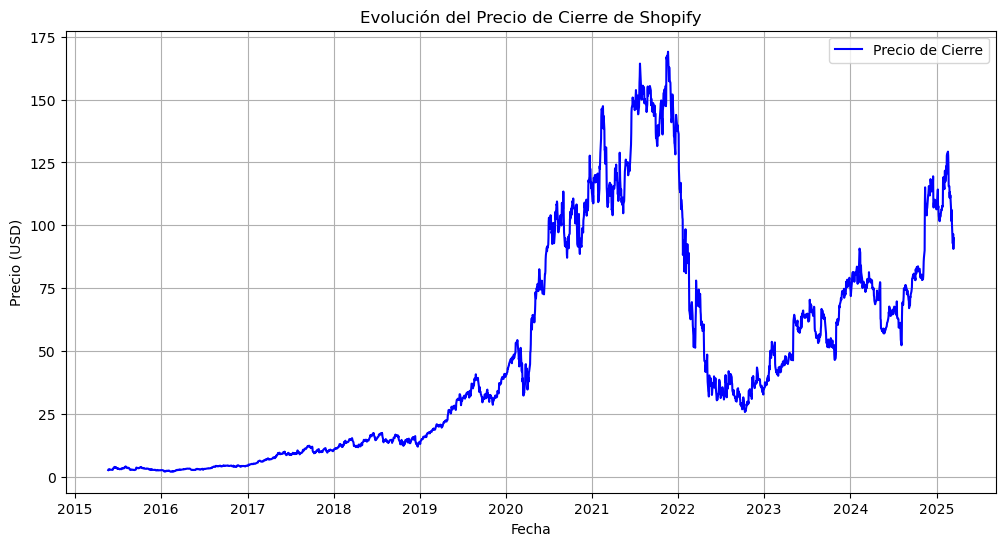

In [34]:
import matplotlib.pyplot as plt
import seaborn as sns

plt.figure(figsize=(12,6))
plt.plot(df['date'], df['close'], label='Precio de Cierre', color='blue')
plt.title('Evolución del Precio de Cierre de Shopify')
plt.xlabel('Fecha')
plt.ylabel('Precio (USD)')
plt.legend()
plt.grid(True)
plt.show()

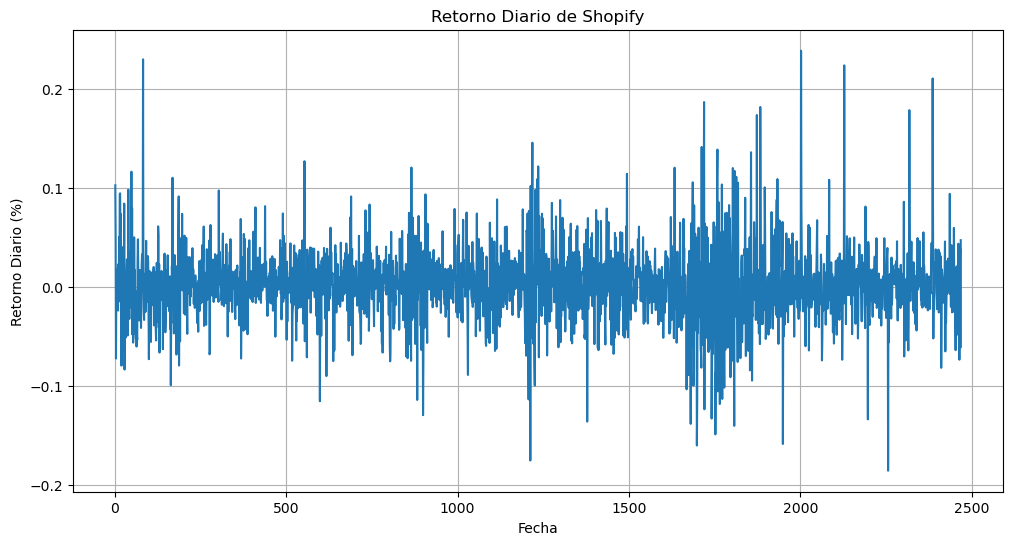

In [35]:
df['daily_return'] = df['close'].pct_change()

plt.figure(figsize=(12,6))
df['daily_return'].plot(title='Retorno Diario de Shopify')
plt.xlabel('Fecha')
plt.ylabel('Retorno Diario (%)')
plt.grid(True)
plt.show()

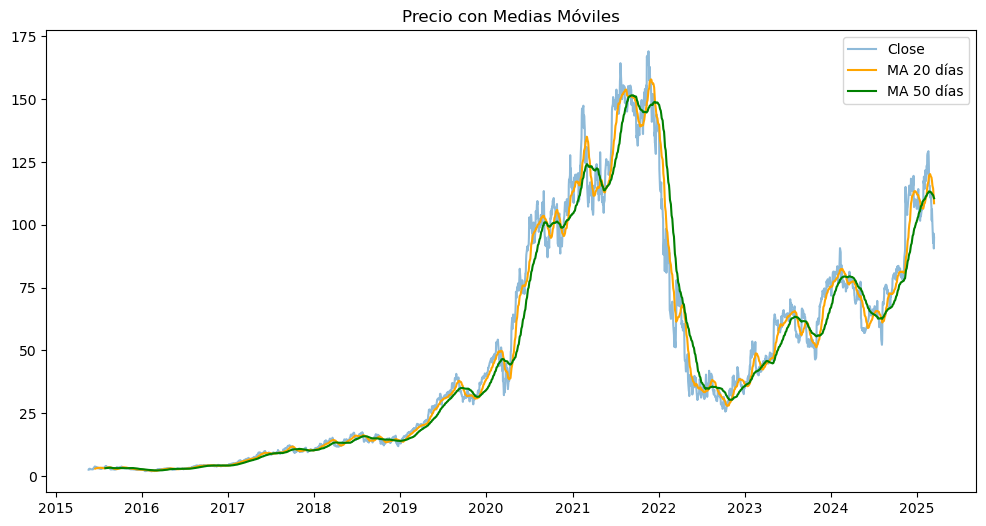

In [36]:
df['MA20'] = df['close'].rolling(20).mean()
df['MA50'] = df['close'].rolling(50).mean()

plt.figure(figsize=(12,6))
plt.plot(df['date'], df['close'], label='Close', alpha=0.5)
plt.plot(df['date'], df['MA20'], label='MA 20 días', color='orange')
plt.plot(df['date'], df['MA50'], label='MA 50 días', color='green')
plt.title('Precio con Medias Móviles')
plt.legend()
plt.show()

In [37]:
top_days = df.sort_values(by='daily_return', ascending=False).head(5)
worst_days = df.sort_values(by='daily_return').head(5)
print("Top 5 mejores días:\n", top_days[['date', 'daily_return']])
print("\nTop 5 peores días:\n", worst_days[['date', 'daily_return']])

Top 5 mejores días:
                     date  daily_return
2002 2023-05-04 04:00:00      0.238383
82   2015-09-17 04:00:00      0.229678
2128 2023-11-02 04:00:00      0.223611
2386 2024-11-12 05:00:00      0.210357
1719 2022-03-18 04:00:00      0.186528

Top 5 peores días:
                     date  daily_return
2256 2024-05-08 04:00:00     -0.185853
1212 2020-03-16 04:00:00     -0.175518
1698 2022-02-16 05:00:00     -0.160371
1949 2023-02-16 05:00:00     -0.158831
1752 2022-05-05 04:00:00     -0.149128


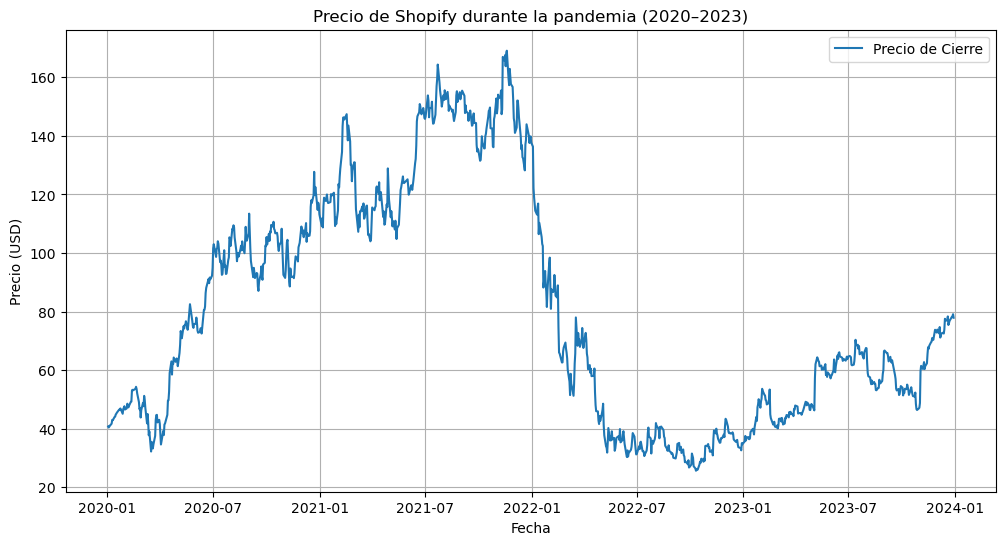

In [38]:
pandemia = df[(df['date'] >= '2020-01-01') & (df['date'] <= '2023-12-31')]
plt.figure(figsize=(12,6))
plt.plot(pandemia['date'], pandemia['close'], label='Precio de Cierre')
plt.title('Precio de Shopify durante la pandemia (2020–2023)')
plt.xlabel('Fecha')
plt.ylabel('Precio (USD)')
plt.grid(True)
plt.legend()
plt.show()


In [40]:
print(df.columns)


Index(['date', 'open', 'high', 'low', 'close', 'adj_close', 'volume',
       'daily_return', 'MA20', 'MA50'],
      dtype='object')


In [41]:
from statsmodels.tsa.stattools import adfuller

# Prueba de Dickey-Fuller
result = adfuller(df['close'])
print('Estadística ADF:', result[0])
print('Valor p:', result[1])


Estadística ADF: -1.3133399708390407
Valor p: 0.6230473775752393


Estadística ADF: -9.117355169478502
Valor p: 3.275017526079799e-15


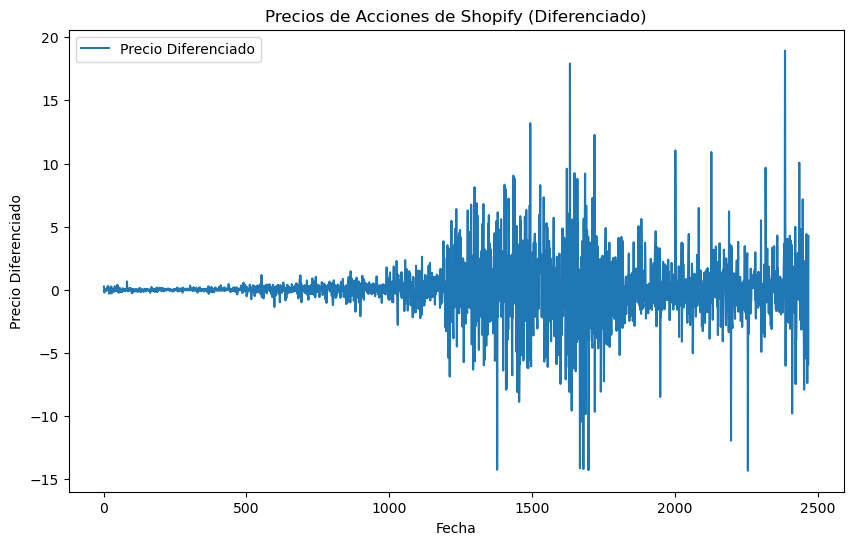

In [42]:
# Diferenciación de primer orden
df['Close_diff'] = df['close'].diff().dropna()

# Verificar si la serie es estacionaria después de la diferenciación
result = adfuller(df['Close_diff'].dropna())
print('Estadística ADF:', result[0])
print('Valor p:', result[1])

# Graficar la serie diferenciada
plt.figure(figsize=(10,6))
plt.plot(df['Close_diff'], label='Precio Diferenciado')
plt.title('Precios de Acciones de Shopify (Diferenciado)')
plt.xlabel('Fecha')
plt.ylabel('Precio Diferenciado')
plt.legend()
plt.show()


In [44]:
pip install pmdarima

Note: you may need to restart the kernel to use updated packages.


In [45]:
from pmdarima import auto_arima

# Modelo ARIMA usando auto_arima
model = auto_arima(df['close'], seasonal=False, stepwise=True, trace=True)
print(model.summary())


Performing stepwise search to minimize aic
 ARIMA(2,1,2)(0,0,0)[0] intercept   : AIC=inf, Time=11.44 sec
 ARIMA(0,1,0)(0,0,0)[0] intercept   : AIC=11065.447, Time=0.16 sec
 ARIMA(1,1,0)(0,0,0)[0] intercept   : AIC=11065.818, Time=0.44 sec
 ARIMA(0,1,1)(0,0,0)[0] intercept   : AIC=11065.832, Time=0.76 sec
 ARIMA(0,1,0)(0,0,0)[0]             : AIC=11064.114, Time=0.15 sec
 ARIMA(1,1,1)(0,0,0)[0] intercept   : AIC=11067.818, Time=0.81 sec

Best model:  ARIMA(0,1,0)(0,0,0)[0]          
Total fit time: 13.993 seconds
                               SARIMAX Results                                
Dep. Variable:                      y   No. Observations:                 2469
Model:               SARIMAX(0, 1, 0)   Log Likelihood               -5531.057
Date:                Fri, 02 May 2025   AIC                          11064.114
Time:                        11:42:10   BIC                          11069.925
Sample:                             0   HQIC                         11066.225
        

In [66]:
from statsmodels.tsa.arima.model import ARIMA

# Entrenar el modelo ARIMA con los parámetros elegidos
model_arima = ARIMA(df['close'], order=(0, 1, 0))  # Sustituye p, d, q por los valores adecuados
model_fitted = model_arima.fit()

# Ver los resultados del modelo
print(model_fitted.summary())

                               SARIMAX Results                                
Dep. Variable:                  close   No. Observations:                 2469
Model:                 ARIMA(0, 1, 0)   Log Likelihood               -5531.057
Date:                Fri, 02 May 2025   AIC                          11064.114
Time:                        11:44:33   BIC                          11069.925
Sample:                             0   HQIC                         11066.225
                               - 2469                                         
Covariance Type:                  opg                                         
                 coef    std err          z      P>|z|      [0.025      0.975]
------------------------------------------------------------------------------
sigma2         5.1776      0.059     87.346      0.000       5.061       5.294
Ljung-Box (L1) (Q):                   1.63   Jarque-Bera (JB):             11055.40
Prob(Q):                              0.20   Pr

C:\Users\jsofi\anaconda3\Lib\site-packages\statsmodels\tsa\base\tsa_model.py:473: ValueWarning: A date index has been provided, but it has no associated frequency information and so will be ignored when e.g. forecasting.
  self._init_dates(dates, freq)
C:\Users\jsofi\anaconda3\Lib\site-packages\statsmodels\tsa\base\tsa_model.py:473: ValueWarning: A date index has been provided, but it has no associated frequency information and so will be ignored when e.g. forecasting.
  self._init_dates(dates, freq)
C:\Users\jsofi\anaconda3\Lib\site-packages\statsmodels\tsa\base\tsa_model.py:473: ValueWarning: A date index has been provided, but it has no associated frequency information and so will be ignored when e.g. forecasting.
  self._init_dates(dates, freq)


In [48]:
# Hacer predicciones para los próximos 10 días
forecast = model.predict(start=len(df), end=len(df) + 9, typ='levels')

# Mostrar las predicciones
print(forecast)


2469    94.849998
2470    94.849998
2471    94.849998
2472    94.849998
2473    94.849998
2474    94.849998
2475    94.849998
2476    94.849998
2477    94.849998
2478    94.849998
dtype: float64


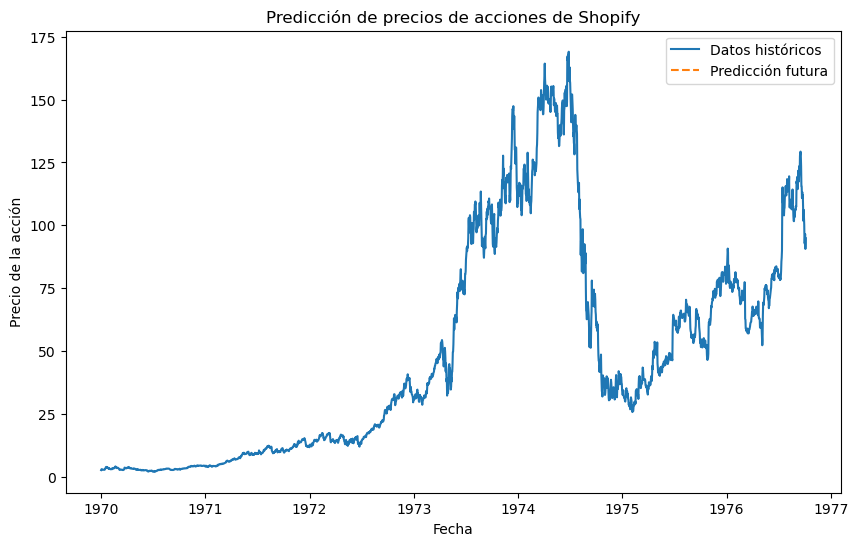

In [50]:
import matplotlib.pyplot as plt

# Crear las fechas para los siguientes 10 días
future_dates = pd.date_range(df.index[-1], periods=11, freq='D')[1:]
predicted_df = pd.DataFrame(forecast, index=future_dates, columns=['Predicted'])

# Graficar los datos históricos y las predicciones
plt.figure(figsize=(10, 6))
plt.plot(df['close'], label='Datos históricos')
plt.plot(predicted_df, label='Predicción futura', linestyle='--')
plt.title('Predicción de precios de acciones de Shopify')
plt.xlabel('Fecha')
plt.ylabel('Precio de la acción')
plt.legend()
plt.show()

C:\Users\jsofi\AppData\Local\Temp\ipykernel_19916\207296345.py:8: FutureWarning: last is deprecated and will be removed in a future version. Please create a mask and filter using `.loc` instead
  last_2_years = df.last('2Y')
C:\Users\jsofi\AppData\Local\Temp\ipykernel_19916\207296345.py:8: FutureWarning: 'Y' is deprecated and will be removed in a future version, please use 'YE' instead.
  last_2_years = df.last('2Y')


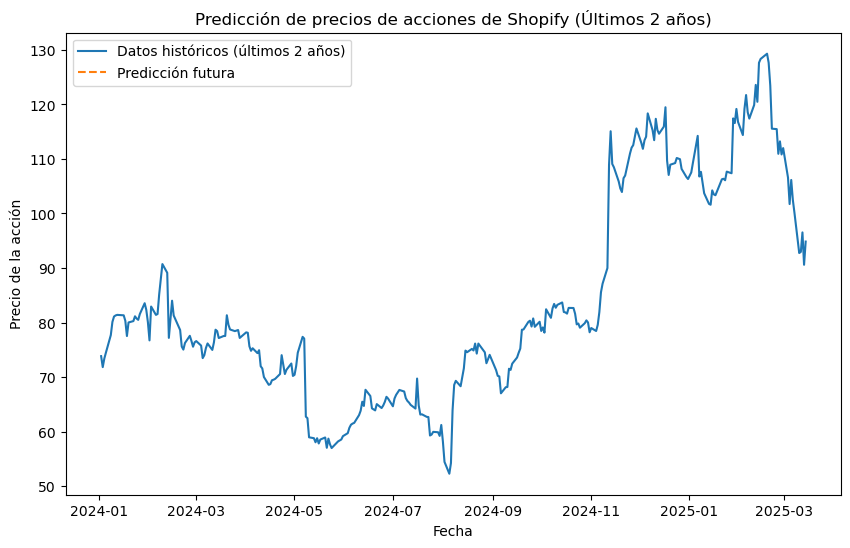

In [51]:
import matplotlib.pyplot as plt

# Convertir el índice de df a datetime si aún no lo es
df['Date'] = pd.to_datetime(df['date'])
df.set_index('Date', inplace=True)

# Filtrar solo los últimos 2 años de datos
last_2_years = df.last('2Y')

# Graficar los últimos 2 años de datos históricos y las predicciones futuras
plt.figure(figsize=(10, 6))
plt.plot(last_2_years['close'], label='Datos históricos (últimos 2 años)')
plt.plot(predicted_df, label='Predicción futura', linestyle='--')
plt.title('Predicción de precios de acciones de Shopify (Últimos 2 años)')
plt.xlabel('Fecha')
plt.ylabel('Precio de la acción')
plt.legend()
plt.show()


In [68]:
# Asegura que 'date' sea datetime y configúrala como índice con frecuencia
df['date'] = pd.to_datetime(df['date'])
df.set_index('date', inplace=True)
df = df.asfreq('B')  # o usa 'D' para todos los días


In [72]:
model = ARIMA(df['close'], order=(2, 1, 1))  # Ajusta esto según lo que hayas decidido
model_fit = model.fit()  # Asegúrate de ajustar el modelo con .fit()

# Ahora puedes hacer predicciones, por ejemplo, para los próximos 10 días
forecast = model_fit.predict(start=len(df), end=len(df)+9)
print(forecast)

2025-03-17 04:00:00    94.373932
2025-03-18 04:00:00    95.012915
2025-03-19 04:00:00    94.646842
2025-03-20 04:00:00    94.890912
2025-03-21 04:00:00    94.733807
2025-03-24 04:00:00    94.835725
2025-03-25 04:00:00    94.769723
2025-03-26 04:00:00    94.812482
2025-03-27 04:00:00    94.784783
2025-03-28 04:00:00    94.802726
Freq: B, Name: predicted_mean, dtype: float64


In [78]:
# Exportar histórico
df.to_csv("shopify_historico.csv", index=False)

# Crear DataFrame de predicciones con fechas
forecast_df = forecast.to_frame(name="predicted_close")
forecast_df.reset_index(inplace=True)
forecast_df.columns = ["date", "predicted_close"]

# Exportar predicciones
forecast_df.to_csv("shopify_forecast.csv", index=False)
